In [1]:
import axelrod as axl
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt


Playing matches:   0%|          | 0/10 [00:00<?, ?it/s]

Analysing: 100%|██████████| 25/25 [00:00<00:00, 138.95it/s]
C:\Users\Ognjen\AppData\Local\Temp\ipykernel_6688\1749101643.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.show()


All strategies


Analysing: 100%|██████████| 25/25 [00:00<00:00, 173.08it/s]
C:\Users\Ognjen\AppData\Local\Temp\ipykernel_6688\1749101643.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.show()


All strategies


...

Analysing: 100%|██████████| 25/25 [00:00<00:00, 142.51it/s]
C:\Users\Ognjen\AppData\Local\Temp\ipykernel_6688\1749101643.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.show()


All strategies


Analysing: 100%|██████████| 25/25 [00:00<00:00, 169.47it/s]


All strategies


C:\Users\Ognjen\AppData\Local\Temp\ipykernel_6688\1749101643.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.show()


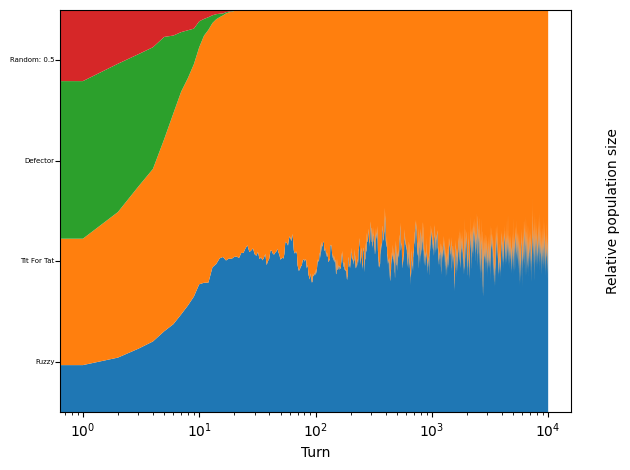

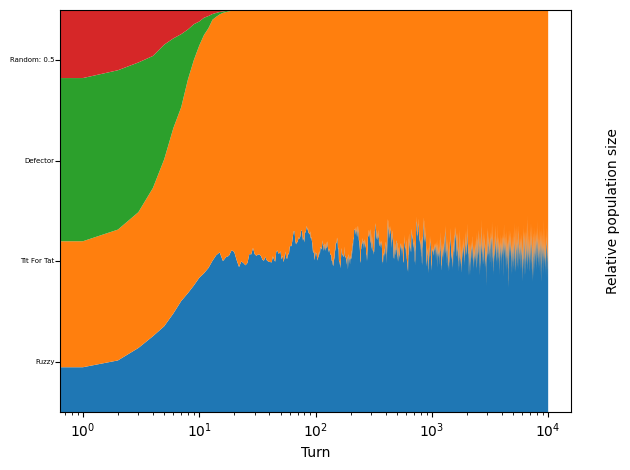

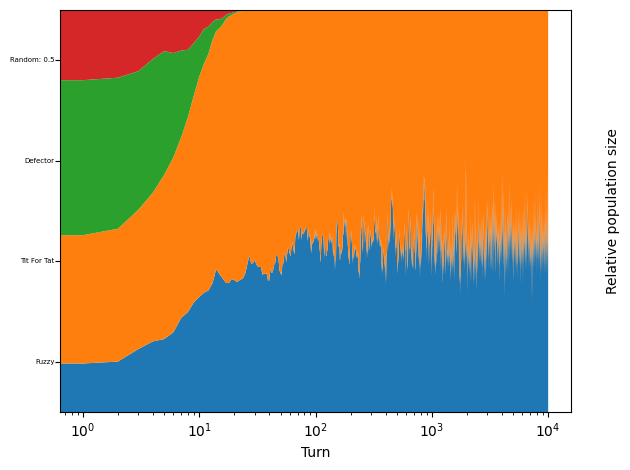

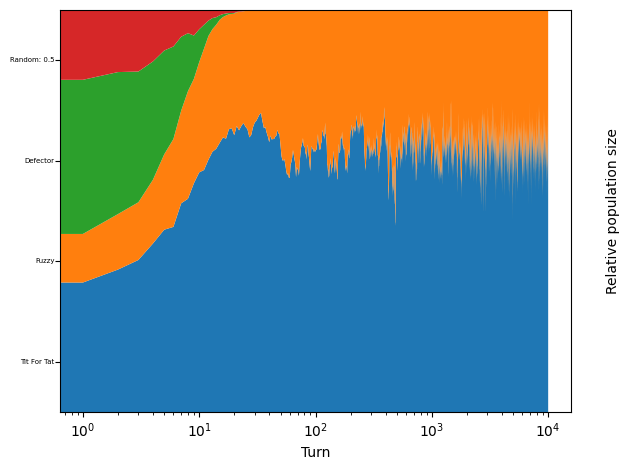

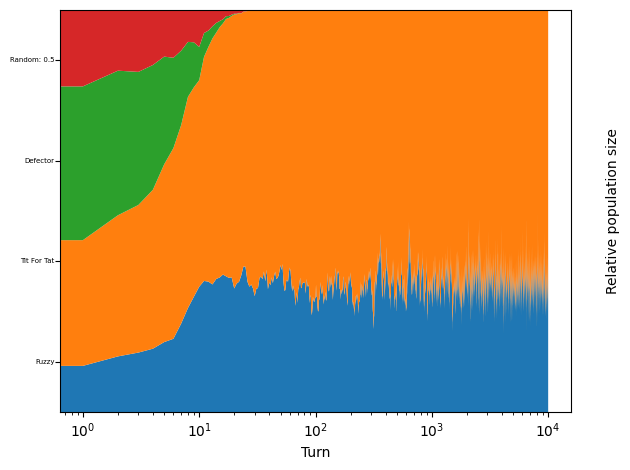

In [2]:
dfs = []


for i in range(0, 5):
    p = [axl.Fuzzy()] + [axl.Defector()] + [axl.Random()] + [axl.TitForTat()]

    t = axl.Tournament(players=p ,noise=0.1)

    results = t.play()

    eco = axl.Ecosystem(results, population=[0.1, 0.4, 0.2, 0.3])
    eco.reproduce(10000)

    plot = axl.Plot(results)
    p = plot.stackplot(eco)
    print("All strategies")
    p.show()

    df = pd.DataFrame({
        "Strategy": [str(player) for player in t.players],
        "Final Population": eco.population_sizes[-1]
    })
    df = df.sort_values(by="Final Population", ascending=False)

    dfs.append(df)

# 5. Save to Excel
j = 0

writer = pd.ExcelWriter('axelrod_final_population_defective_tft_noise.xlsx', engine='xlsxwriter')

for df in dfs:
    df.to_excel(writer, sheet_name=str(j), index=False)
    j += 1

writer.close()
